## Recitation 5: FD Cont'd + FV Prerequisites

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

%matplotlib inline

### Problem 1

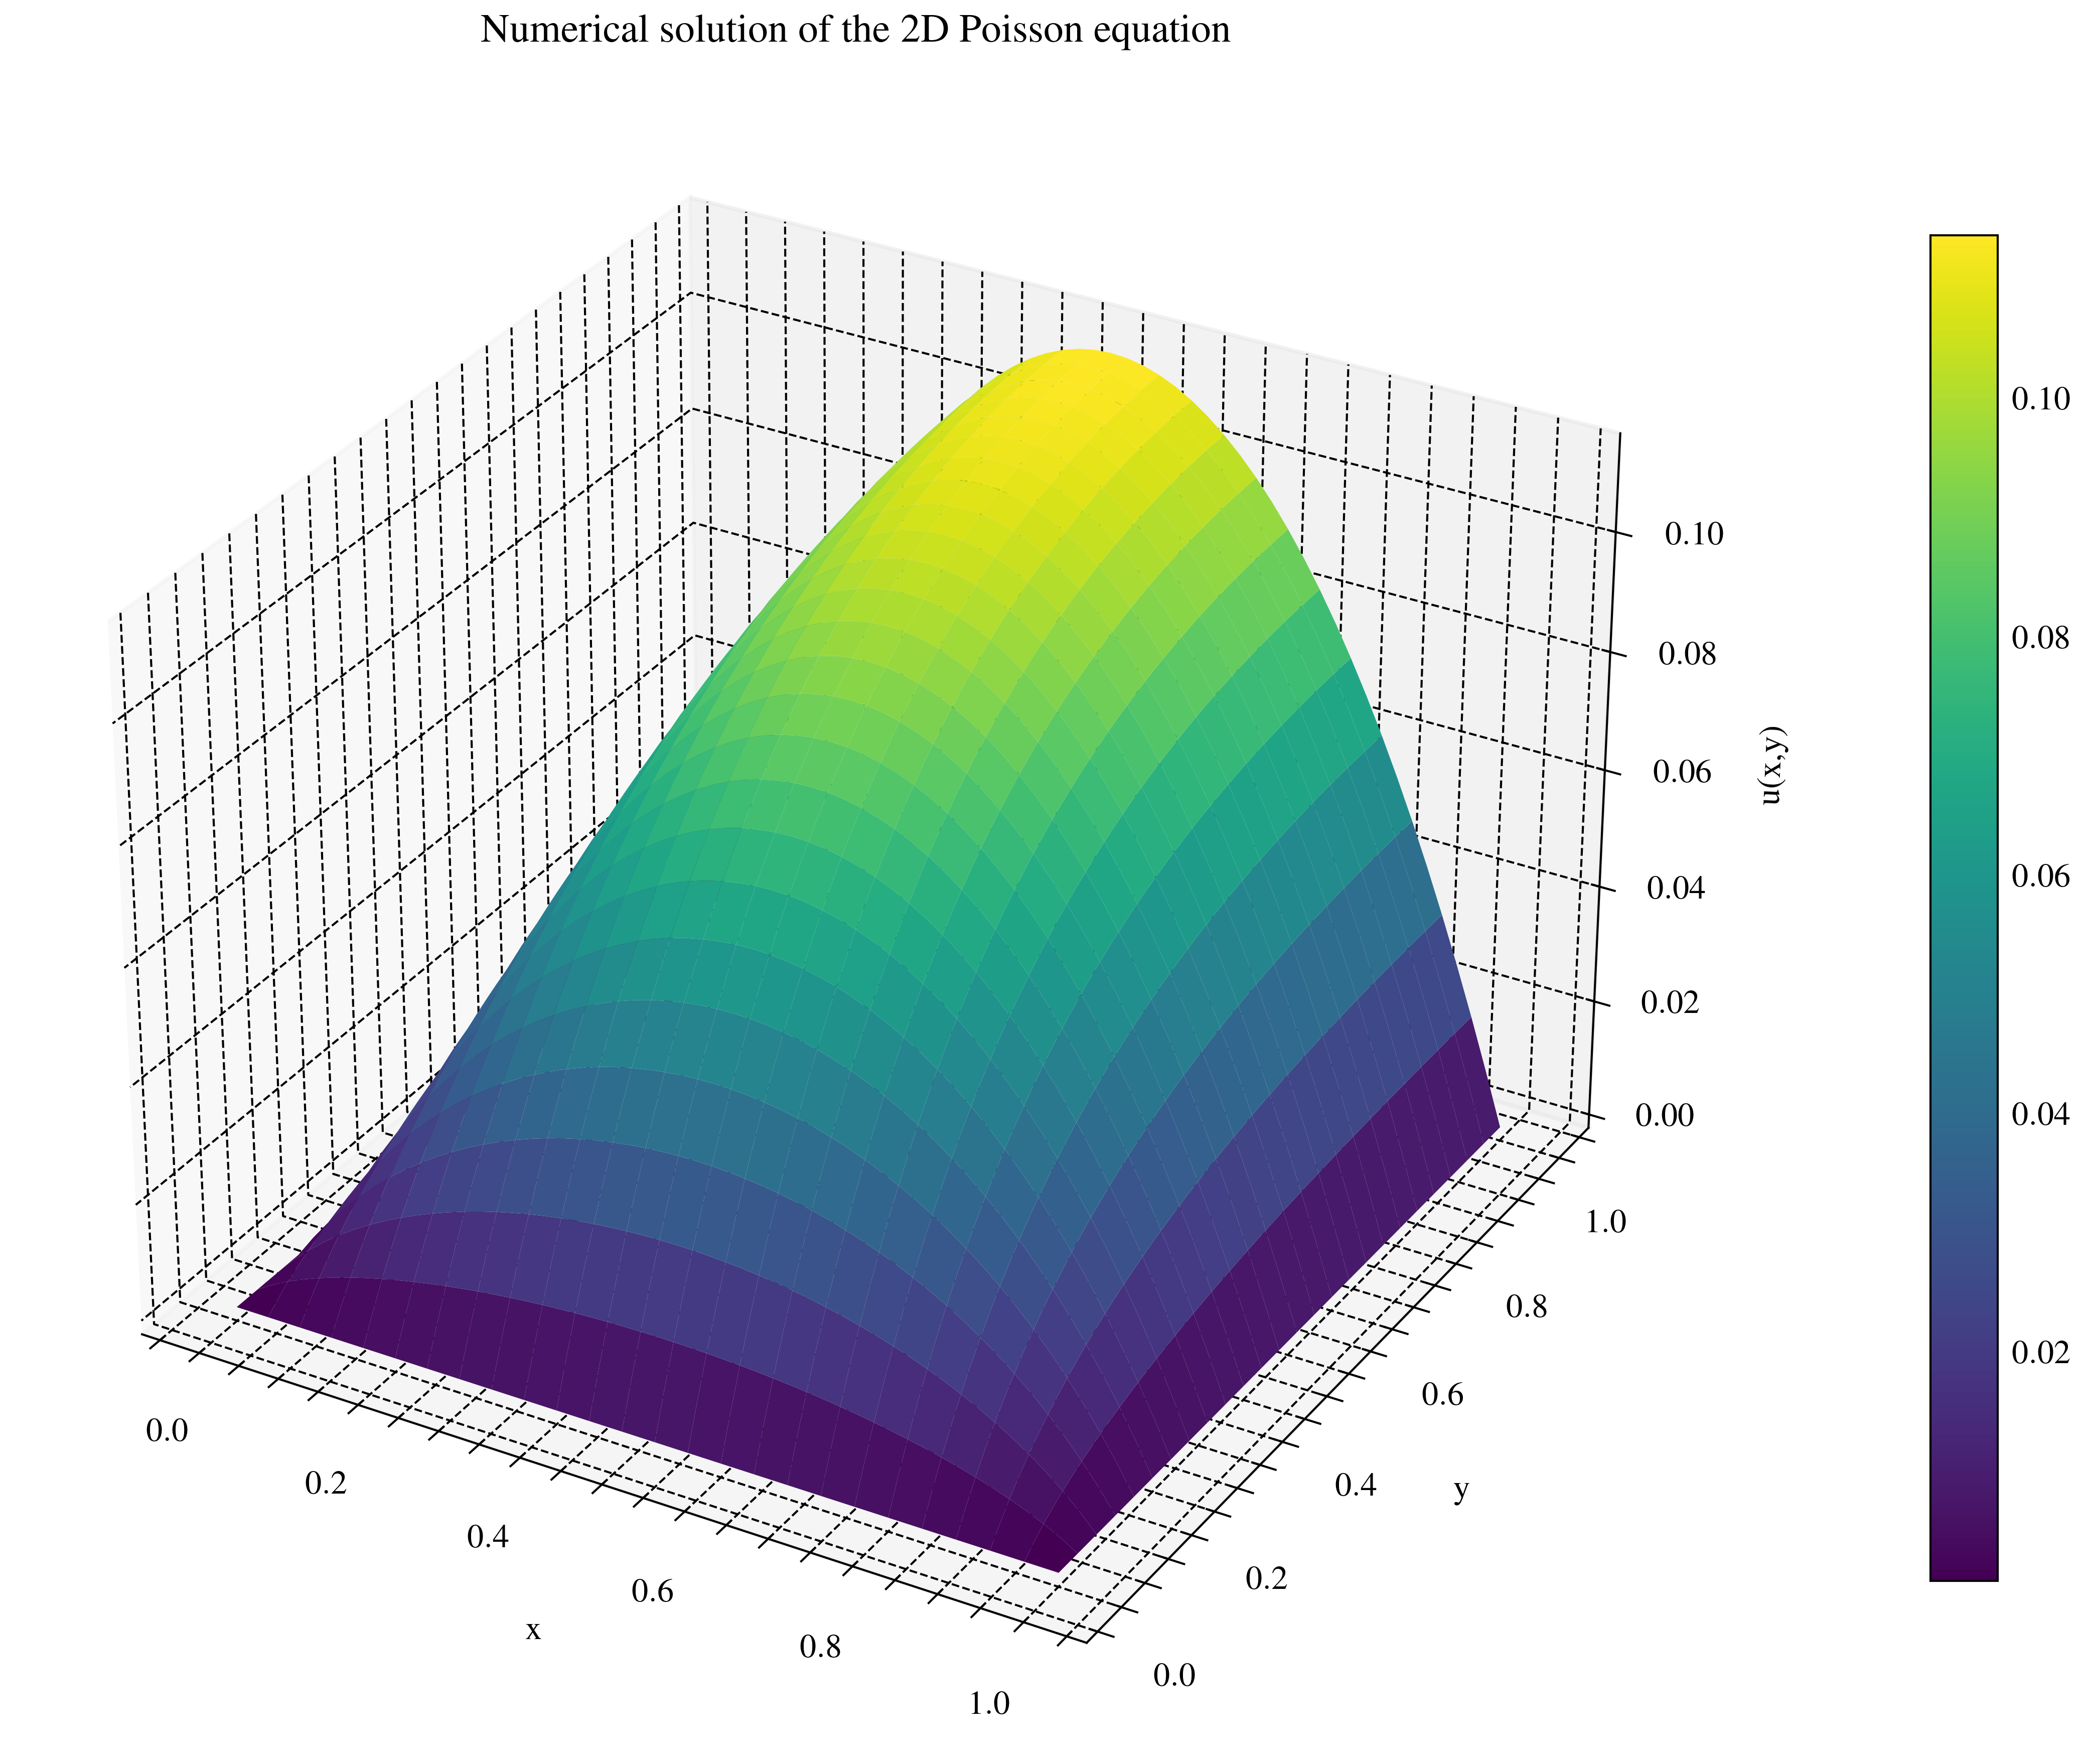

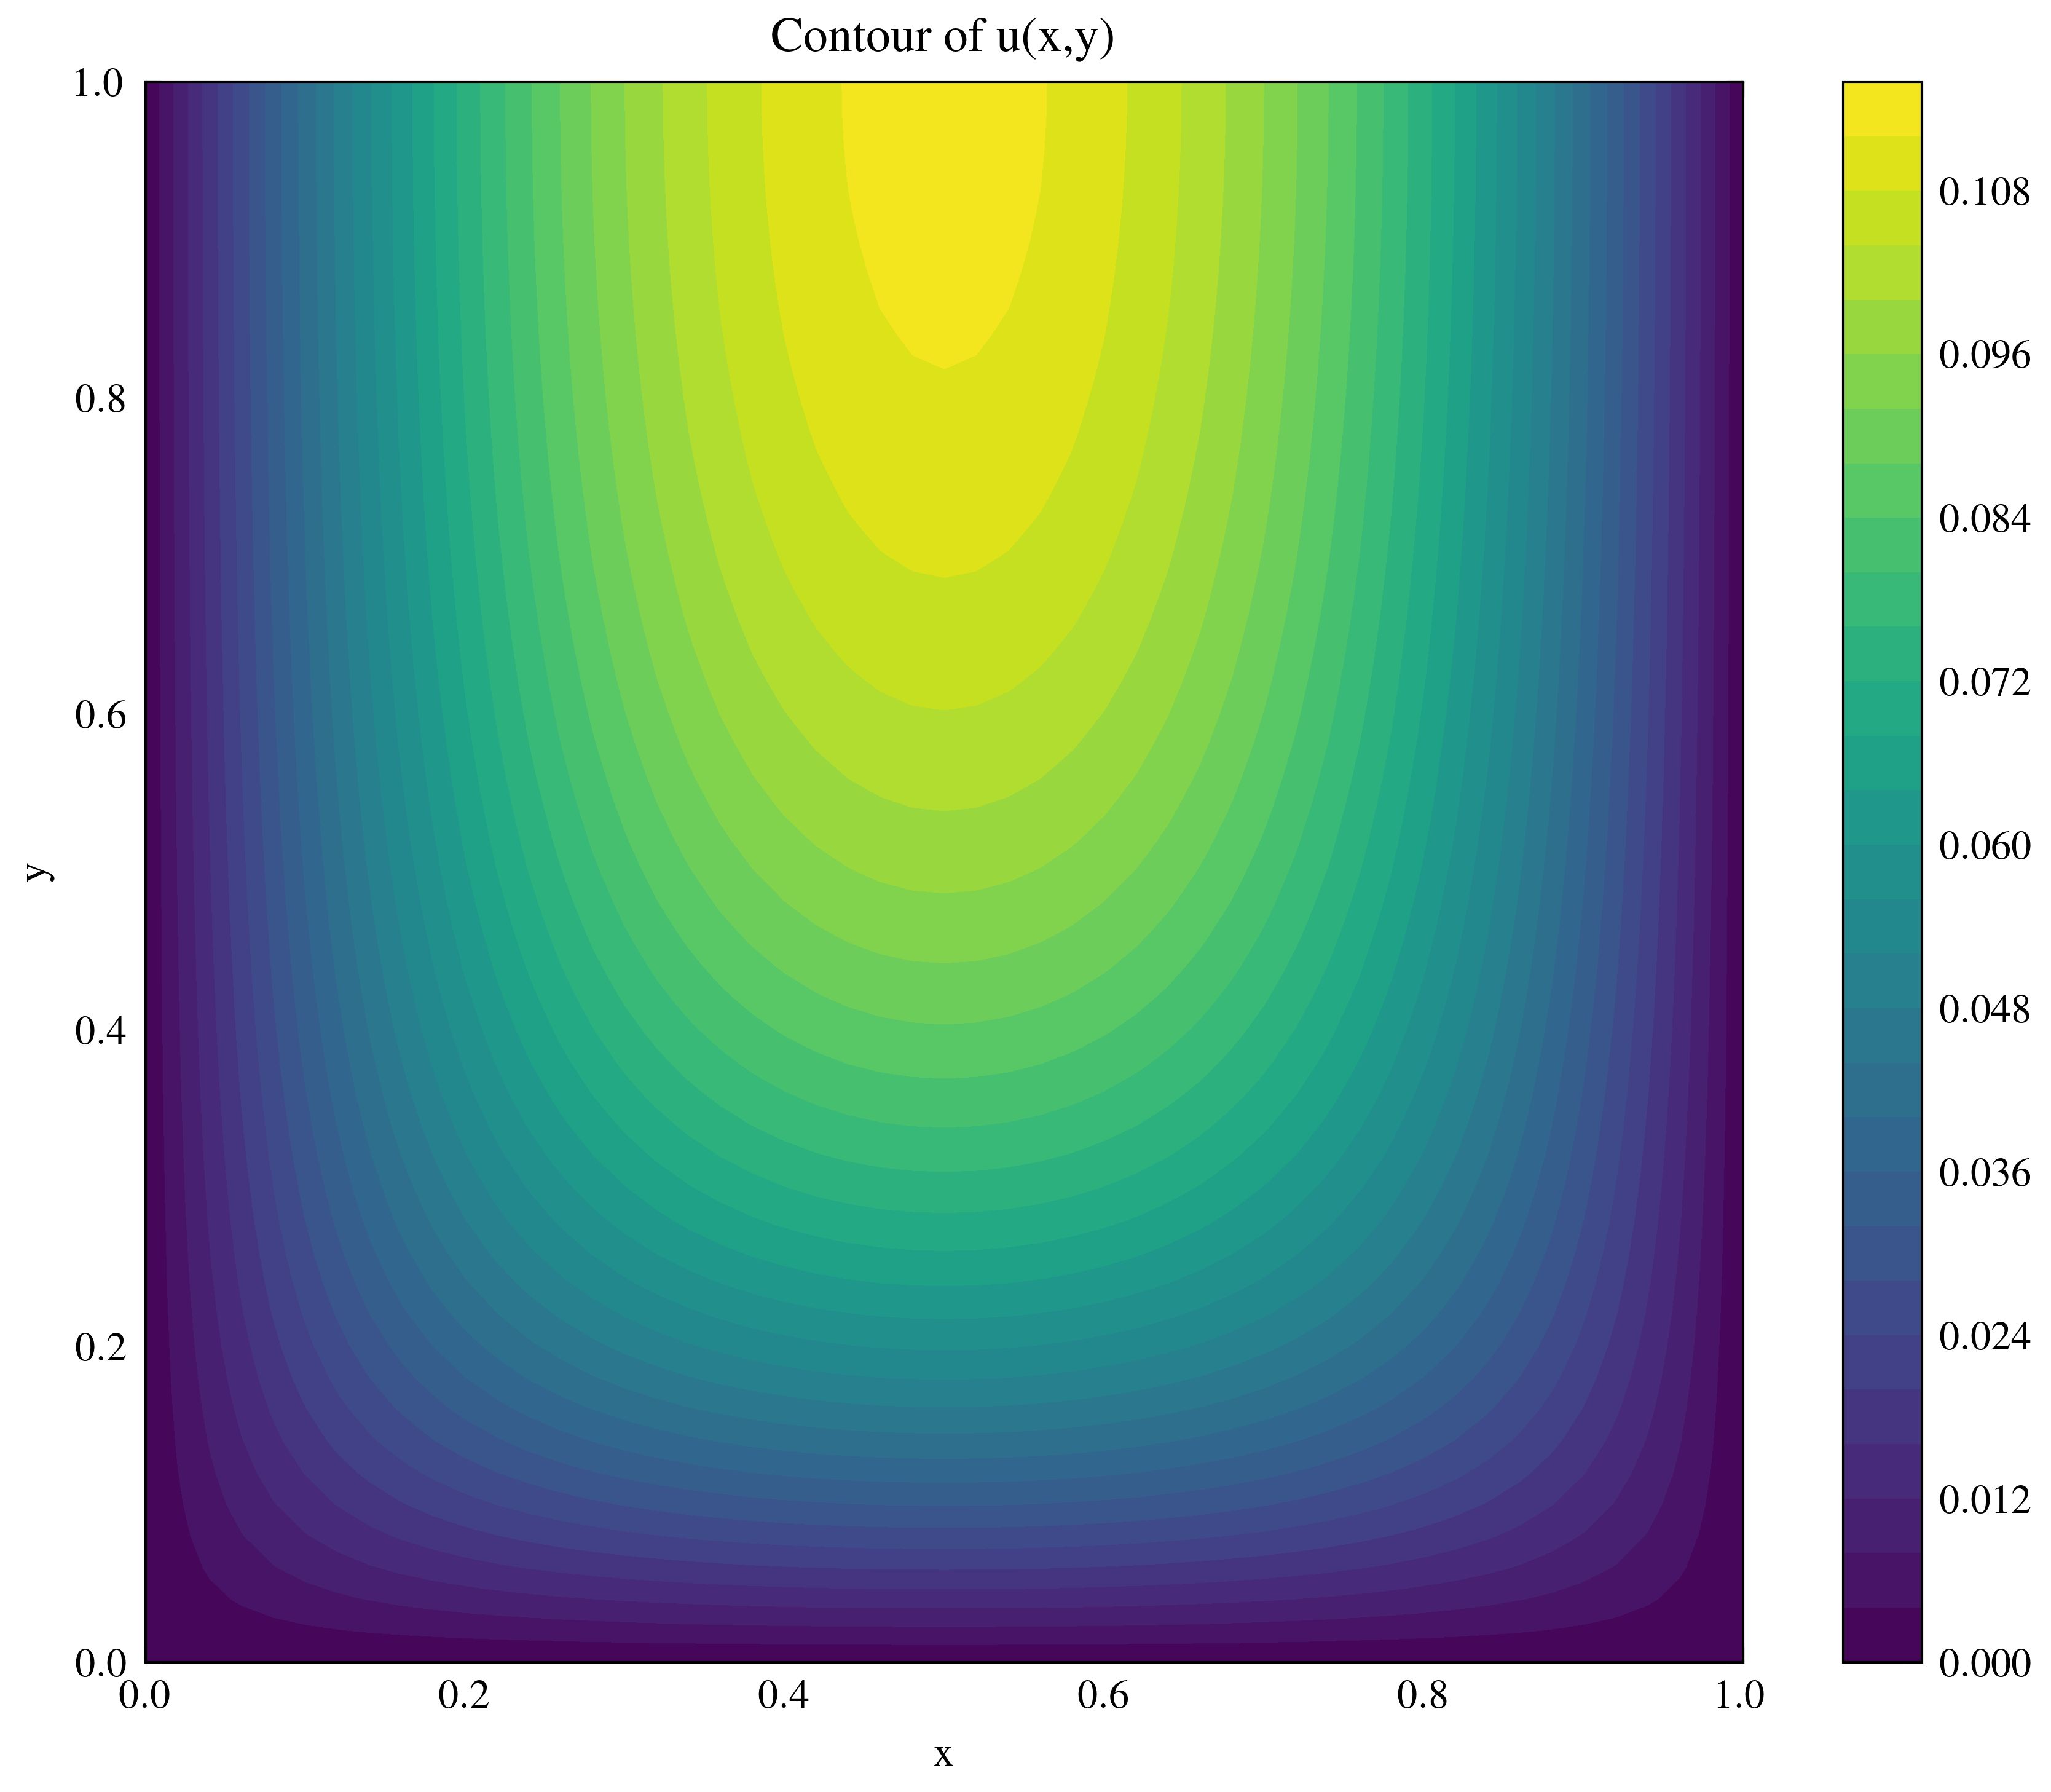

In [2]:
# --------------------------------------------------
# Grid size
# --------------------------------------------------
N = 50  # h = 1/N
h = 1.0 / N
nx = N - 1  # unknowns in x-direction
ny = N  # unknowns in y-direction (including top boundary)

# --------------------------------------------------
# Construct A_x
# --------------------------------------------------
ex = np.ones(nx)
Ax = diags(
    diagonals=[-ex[:-1], 2.0 * ex, -ex[:-1]],
    offsets=[-1, 0, 1],
    shape=(nx, nx),
    format="csr",
)

# --------------------------------------------------
# Construct A_y
# --------------------------------------------------
ey = np.ones(ny)
Ay = diags(
    diagonals=[-ey[:-1], 2.0 * ey, -ey[:-1]],
    offsets=[-1, 0, 1],
    shape=(ny, ny),
    format="lil",
)
Ay[-1, -2] = -2.0  # modify last row for Neumann BC
Ay = Ay.tocsr()

# --------------------------------------------------
# Assemble K2D
# --------------------------------------------------
K = (kron(identity(ny), Ax) + kron(Ay, identity(nx))) / h**2

# Right-hand side
f = np.ones(nx * ny)

# --------------------------------------------------
# Solve linear system
# --------------------------------------------------
u_vec = spsolve(K, f)

# --------------------------------------------------
# Recover solution on the full grid
# Ufull[j, i] corresponds to y_j, x_i
# --------------------------------------------------
Ufull = np.zeros((N + 1, N + 1))
Ufull[1 : N + 1, 1:N] = u_vec.reshape(ny, nx)

x = np.linspace(0, 1, N + 1)
y = np.linspace(0, 1, N + 1)
X, Y = np.meshgrid(x, y)

# --------------------------------------------------
# 3D surface plot
# --------------------------------------------------
plt.style.use(["science", "ieee", "grid"])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, Ufull, cmap="viridis", edgecolor="none")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")
ax.set_title("Numerical solution of the 2D Poisson equation")
fig.colorbar(surf, shrink=0.8, pad=0.1)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Contour plot
# --------------------------------------------------
plt.figure(figsize=(6, 5))
cont = plt.contourf(X, Y, Ufull, levels=30, cmap="viridis")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour of u(x,y)")
plt.colorbar(cont)
plt.tight_layout()
plt.show()

### Problem 2

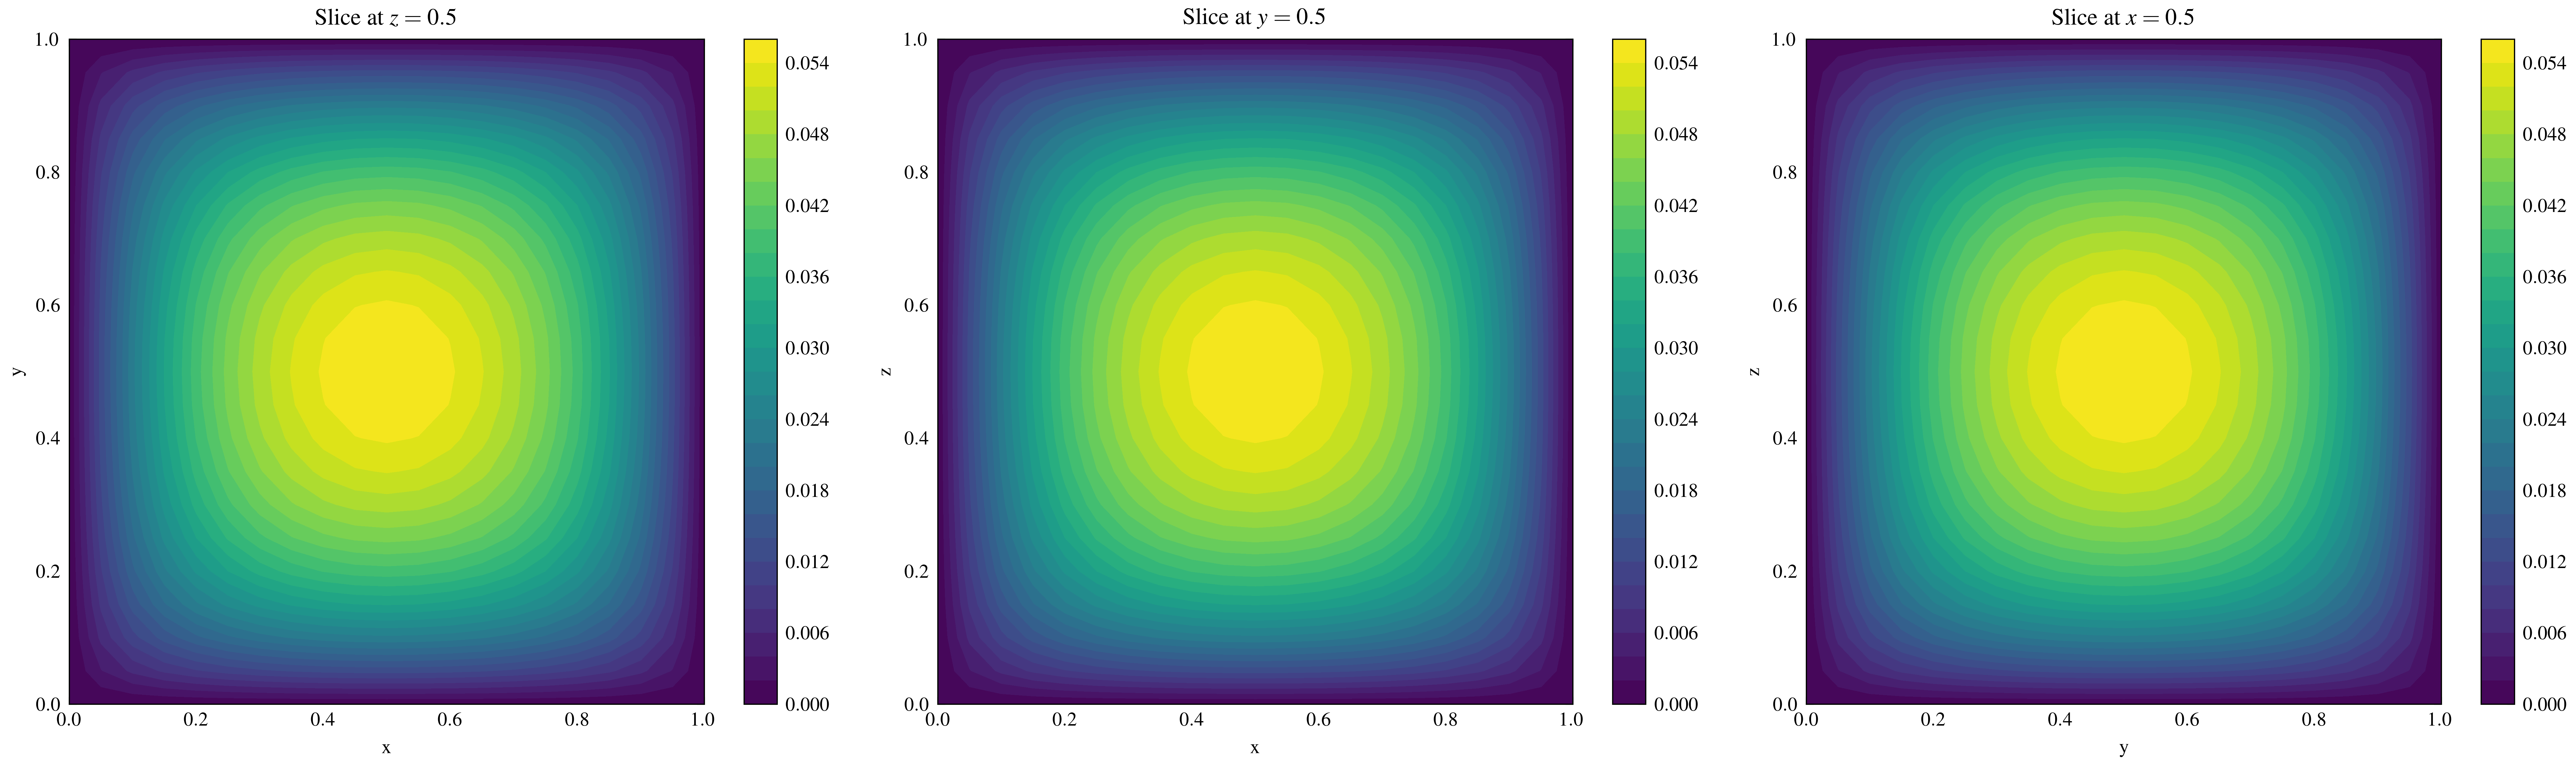

Maximum value of u = 0.05599981478410857
Approximate location = (np.float64(0.5), np.float64(0.5), np.float64(0.5))


In [3]:
# --------------------------------------------------
# Grid setting
# --------------------------------------------------
N = 20  # number of intervals in each direction
h = 1.0 / N
n = N - 1  # number of interior points in each direction

# --------------------------------------------------
# 1D operator K1D = (1/h^2) * T_n
# --------------------------------------------------
e = np.ones(n)
T = diags(
    diagonals=[-e[:-1], 2.0 * e, -e[:-1]],
    offsets=[-1, 0, 1],
    shape=(n, n),
    format="csr",
)
I1D = identity(n, format="csr")
K1D = T / h**2

# --------------------------------------------------
# 2D operator K2D = I ⊗ K1D + K1D ⊗ I
# --------------------------------------------------
I2D = identity(n * n, format="csr")
K2D = kron(I1D, K1D) + kron(K1D, I1D)

# --------------------------------------------------
# 3D operator K3D = I ⊗ K2D + K1D ⊗ I
# --------------------------------------------------
K3D = kron(I1D, K2D) + kron(K1D, I2D)

# Right-hand side
f = np.ones(n**3)

# --------------------------------------------------
# Solve the linear system
# --------------------------------------------------
u_vec = spsolve(K3D, f)

# --------------------------------------------------
# Reshape to 3D interior array
# U[k, j, i] corresponds to z_k, y_j, x_i
# --------------------------------------------------
U = u_vec.reshape((n, n, n))

# Embed into the full grid including boundary values
Ufull = np.zeros((N + 1, N + 1, N + 1))
Ufull[1:N, 1:N, 1:N] = U

x = np.linspace(0, 1, N + 1)
y = np.linspace(0, 1, N + 1)
z = np.linspace(0, 1, N + 1)

# --------------------------------------------------
# Mid-plane slices
# --------------------------------------------------
ix = N // 2
iy = N // 2
iz = N // 2

plt.style.use(["science", "ieee", "grid"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Slice z = 0.5
im1 = axes[0].contourf(x, y, Ufull[iz, :, :], levels=30, cmap="viridis")
axes[0].set_title(r"Slice at $z=0.5$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im1, ax=axes[0])

# Slice y = 0.5
im2 = axes[1].contourf(x, z, Ufull[:, iy, :], levels=30, cmap="viridis")
axes[1].set_title(r"Slice at $y=0.5$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
plt.colorbar(im2, ax=axes[1])

# Slice x = 0.5
im3 = axes[2].contourf(y, z, Ufull[:, :, ix], levels=30, cmap="viridis")
axes[2].set_title(r"Slice at $x=0.5$")
axes[2].set_xlabel("y")
axes[2].set_ylabel("z")
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Maximum value and its approximate location
# --------------------------------------------------
max_index = np.unravel_index(np.argmax(Ufull), Ufull.shape)
print("Maximum value of u =", Ufull[max_index])
print("Approximate location =", (x[max_index[2]], y[max_index[1]], z[max_index[0]]))

### Problem 4

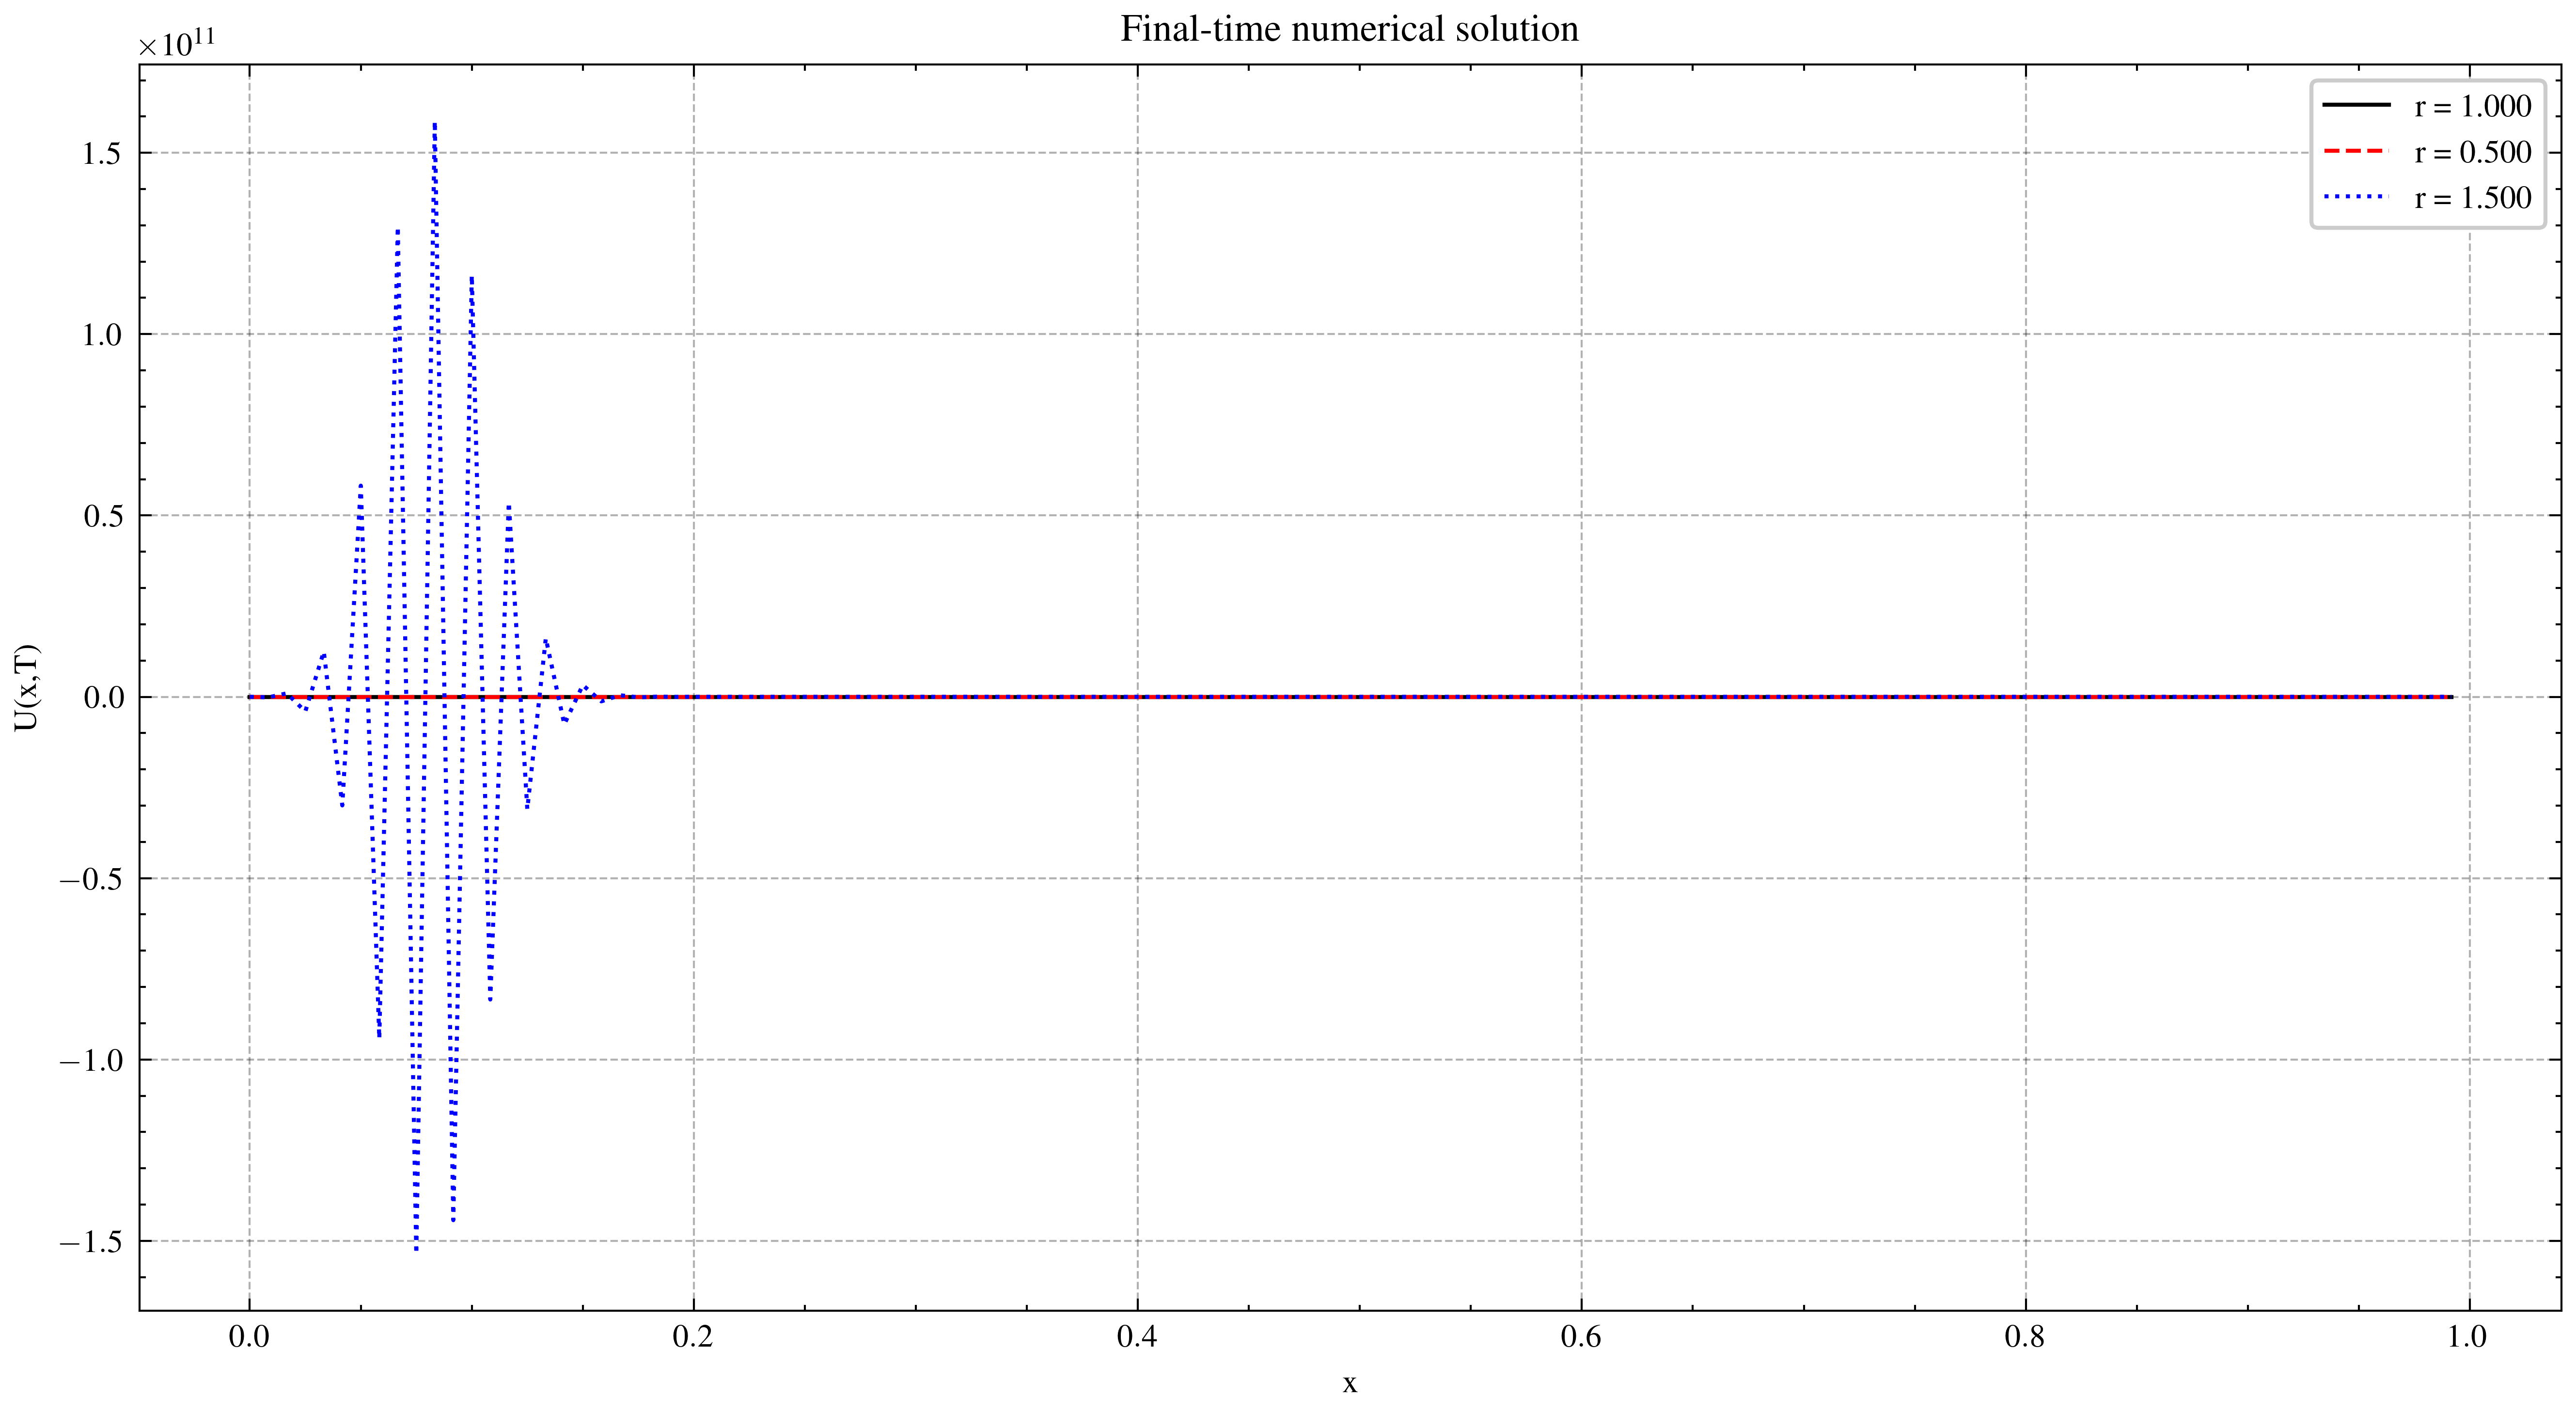

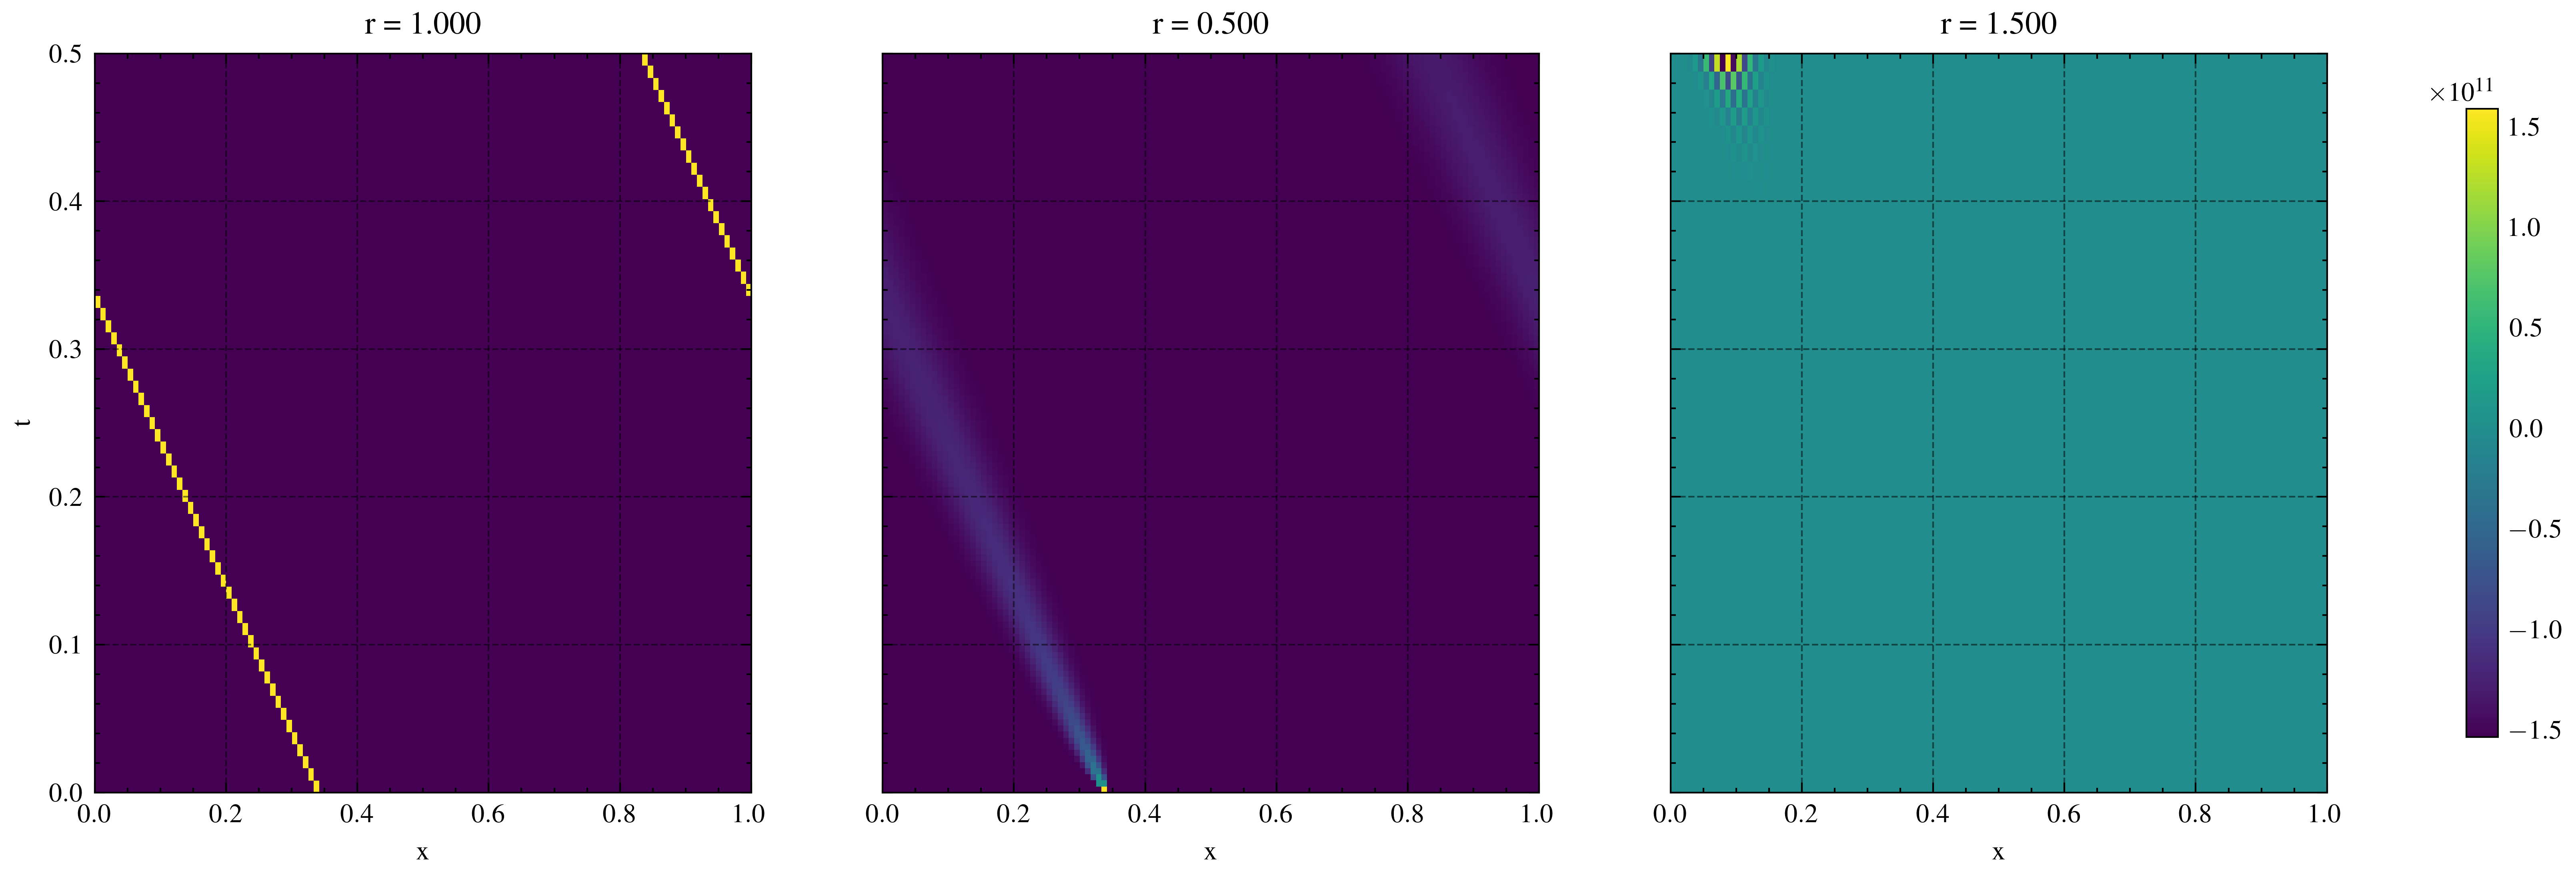

In [4]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
c = 1.0
Nx = 120
x = np.linspace(0, 1, Nx, endpoint=False)
dx = 1.0 / Nx
T = 0.5

# Discrete delta pulse near x = 1/3
x0 = 1.0 / 3.0
j0 = np.argmin(np.abs(x - x0))


def upwind_left_moving(r, T, Nx):
    dx = 1.0 / Nx
    dt = r * dx / c
    Nt = int(np.ceil(T / dt))
    dt = T / Nt
    r = c * dt / dx

    U = np.zeros(Nx)
    U[j0] = 1.0  # Kronecker delta for visualization

    history = [U.copy()]

    for n in range(Nt):
        Unew = np.zeros_like(U)
        for j in range(Nx):
            jp = (j + 1) % Nx  # periodic index
            Unew[j] = U[j] + r * (U[jp] - U[j])
        U = Unew
        history.append(U.copy())

    return np.array(history), r, dt


r_values = [1.0, 0.5, 1.5]
results = {}

for r in r_values:
    history, r_eff, dt = upwind_left_moving(r, T, Nx)
    results[r] = (history, r_eff, dt)

# --------------------------------------------------
# Final-time comparison
# --------------------------------------------------
plt.style.use(["science", "ieee", "grid"])

plt.figure(figsize=(9, 5))
for r in r_values:
    history, r_eff, dt = results[r]
    plt.plot(x, history[-1], label=f"r = {r_eff:.3f}")

plt.xlabel("x")
plt.ylabel("U(x,T)")
plt.title("Final-time numerical solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Space-time plots
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, r in zip(axes, r_values):
    history, r_eff, dt = results[r]
    im = ax.imshow(
        history, aspect="auto", origin="lower", extent=[0, 1, 0, T], cmap="viridis"
    )
    ax.set_title(f"r = {r_eff:.3f}")
    ax.set_xlabel("x")

axes[0].set_ylabel("t")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
# plt.tight_layout()
plt.show()